In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load data (same as before)
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

X = df.drop('target', axis=1)
y = df['target']

# Split first, BEFORE resizing numbers - keeps the test set truly hidden/fair
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Resize all number columns so they're on a comparable scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up all 4 guessing methods in one place
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# Train each one, test each one, save its scores
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

# Turn the results into a clean table
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision   Recall  F1 Score
0  Logistic Regression  0.852459   0.870968  0.84375  0.857143
1        Random Forest  0.836066   0.843750  0.84375  0.843750
2                  SVM  0.868852   0.900000  0.84375  0.870968
3                  KNN  0.901639   0.933333  0.87500  0.903226


In [ ]:
import pandas as pd

# Load the multi-hospital file directly from your GitHub repo
url = "https://raw.githubusercontent.com/varmahardik74/Heart-Disease-Paper/main/Heart_disease_Dataset%20%20-%20heart_disease_uci.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print()

# How many patients came from each hospital
print("Patients per hospital:")
print(df['dataset'].value_counts())
print()

# Look at the exact category names used in each text column
# We need these EXACT spellings before converting them to numbers
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

Shape: (920, 16)

Patients per hospital:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

--- sex ---
['Male' 'Female']

--- cp ---
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

--- fbs ---
[True False nan]

--- restecg ---
['lv hypertrophy' 'normal' 'st-t abnormality' nan]

--- exang ---
[False True nan]

--- slope ---
['downsloping' 'flat' 'upsloping' nan]

--- thal ---
['fixed defect' 'normal' 'reversable defect' nan]



In [ ]:
# Define the exact mapping for each category column
mappings = {
    'sex': {'Female': 0, 'Male': 1},
    'cp': {'typical angina': 0, 'atypical angina': 1, 'non-anginal': 2, 'asymptomatic': 3},
    'fbs': {False: 0, True: 1},
    'restecg': {'normal': 0, 'st-t abnormality': 1, 'lv hypertrophy': 2},
    'exang': {False: 0, True: 1},
    'slope': {'upsloping': 0, 'flat': 1, 'downsloping': 2},
    'thal': {'normal': 0, 'fixed defect': 1, 'reversable defect': 2}
}

# Apply each mapping - any existing missing value (nan) stays as nan, untouched
for col, mapping in mappings.items():
    df[col] = df[col].map(mapping)

# Check it worked correctly - each column should now show only numbers (and nan where data was missing)
for col in mappings.keys():
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

# Also confirm the whole table's data types
print(df.dtypes)

--- sex ---
[1 0]

--- cp ---
[0 3 2 1]

--- fbs ---
[ 1.  0. nan]

--- restecg ---
[ 2.  0.  1. nan]

--- exang ---
[ 0.  1. nan]

--- slope ---
[ 2.  1.  0. nan]

--- thal ---
[ 1.  0.  2. nan]

id            int64
age           int64
sex           int64
dataset      object
cp            int64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalch      float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object


In [ ]:
# Fix the target: convert 0-4 severity scale into simple 0/1 (disease present or not)
df['num'] = (df['num'] > 0).astype(int)

# The 10 reliable features we decided on last time (dropping ca, thal, slope)
common_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak']
target = 'num'

# Split into 4 separate hospital datasets - this is the "split by hospital, not randomly" step
cleveland     = df[df['dataset'] == 'Cleveland'][common_features + [target]].copy()
hungary       = df[df['dataset'] == 'Hungary'][common_features + [target]].copy()
switzerland   = df[df['dataset'] == 'Switzerland'][common_features + [target]].copy()
va_long_beach = df[df['dataset'] == 'VA Long Beach'][common_features + [target]].copy()

print("Cleveland:", cleveland.shape)
print("Hungary:", hungary.shape)
print("Switzerland:", switzerland.shape)
print("VA Long Beach:", va_long_beach.shape)
print()

# Sanity check: missing values should now be small (a handful to ~25%),
# not the 90%+ we saw before dropping ca/thal/slope
print("Remaining missing values per hospital:")
for name, site_df in [('Cleveland', cleveland), ('Hungary', hungary), ('Switzerland', switzerland), ('VA Long Beach', va_long_beach)]:
    print(f"--- {name} ---")
    missing = site_df.isnull().sum()
    print(missing[missing > 0] if missing.sum() > 0 else "No missing values")
    print()

# Also confirm the target split looks reasonable in each hospital
print("Disease (1) vs No Disease (0) count per hospital:")
for name, site_df in [('Cleveland', cleveland), ('Hungary', hungary), ('Switzerland', switzerland), ('VA Long Beach', va_long_beach)]:
    print(f"{name}: {site_df['num'].value_counts().to_dict()}")

Cleveland: (304, 11)
Hungary: (293, 11)
Switzerland: (123, 11)
VA Long Beach: (200, 11)

Remaining missing values per hospital:
--- Cleveland ---
No missing values

--- Hungary ---
trestbps     1
chol        23
fbs          8
restecg      1
thalch       1
exang        1
dtype: int64

--- Switzerland ---
trestbps     2
fbs         75
restecg      1
thalch       1
exang        1
oldpeak      6
dtype: int64

--- VA Long Beach ---
trestbps    56
chol         7
fbs          7
thalch      53
exang       53
oldpeak     56
dtype: int64

Disease (1) vs No Disease (0) count per hospital:
Cleveland: {0: 165, 1: 139}
Hungary: {0: 187, 1: 106}
Switzerland: {1: 115, 0: 8}
VA Long Beach: {1: 149, 0: 51}


In [ ]:
# Compute fill-in values using ONLY Cleveland (our training hospital)
# Numeric columns get filled with the median, category columns get filled with the most common value (mode)
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
categorical_cols = ['fbs', 'restecg', 'exang']

fill_values = {}
for col in numeric_cols:
    fill_values[col] = cleveland[col].median()
for col in categorical_cols:
    fill_values[col] = cleveland[col].mode()[0]

print("Fill-in values, computed from Cleveland only:")
print(fill_values)
print()

# Apply these SAME fill-in values to all 4 hospitals
# We deliberately do NOT recalculate these from Hungary/Switzerland/VA Long Beach themselves -
# doing so would let each hospital "help itself," which would make later results look better than they honestly are
for name, site_df in [('Cleveland', cleveland), ('Hungary', hungary), ('Switzerland', switzerland), ('VA Long Beach', va_long_beach)]:
    site_df.fillna(fill_values, inplace=True)

# Confirm nothing is missing anywhere now
print("Missing values remaining after filling:")
for name, site_df in [('Cleveland', cleveland), ('Hungary', hungary), ('Switzerland', switzerland), ('VA Long Beach', va_long_beach)]:
    print(f"{name}: {site_df.isnull().sum().sum()} missing values total")

Fill-in values, computed from Cleveland only:
{'trestbps': 130.0, 'chol': 240.5, 'thalch': 153.0, 'oldpeak': 0.8, 'fbs': np.float64(0.0), 'restecg': np.float64(0.0), 'exang': np.float64(0.0)}

Missing values remaining after filling:
Cleveland: 0 missing values total
Hungary: 0 missing values total
Switzerland: 0 missing values total
VA Long Beach: 0 missing values total


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(cleveland[common_features])  # fit ONLY on Cleveland

for name, site_df in [('Cleveland', cleveland), ('Hungary', hungary), ('Switzerland', switzerland), ('VA Long Beach', va_long_beach)]:
    site_df[common_features] = scaler.transform(site_df[common_features])

print("Cleveland mean/std (should be ~0 / ~1):")
print(cleveland[common_features].mean().round(2).to_dict())
print(cleveland[common_features].std().round(2).to_dict())

print("\nHungary mean/std (won't be 0/1 - that's expected, shows how different it is):")
print(hungary[common_features].mean().round(2).to_dict())

Cleveland mean/std (should be ~0 / ~1):
{'age': -0.0, 'sex': -0.0, 'cp': 0.0, 'trestbps': 0.0, 'chol': -0.0, 'fbs': 0.0, 'restecg': -0.0, 'thalch': -0.0, 'exang': 0.0, 'oldpeak': 0.0}
{'age': 1.0, 'sex': 1.0, 'cp': 1.0, 'trestbps': 1.0, 'chol': 1.0, 'fbs': 1.0, 'restecg': 1.0, 'thalch': 1.0, 'exang': 1.0, 'oldpeak': 1.0}

Hungary mean/std (won't be 0/1 - that's expected, shows how different it is):
{'age': -0.71, 'sex': 0.09, 'cp': -0.18, 'trestbps': 0.05, 'chol': 0.08, 'fbs': -0.22, 'restecg': -0.79, 'thalch': -0.47, 'exang': -0.05, 'oldpeak': -0.39}


In [ ]:
cleveland.to_csv('cleveland_cleaned.csv', index=False)
hungary.to_csv('hungary_cleaned.csv', index=False)
switzerland.to_csv('switzerland_cleaned.csv', index=False)
va_long_beach.to_csv('va_long_beach_cleaned.csv', index=False)
print("Saved 4 files - check the folder icon on the left sidebar")

Saved 4 files - check the folder icon on the left sidebar


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Split Cleveland into a training part and its own hold-out test part (same idea as Day 1)
X_cleveland = cleveland[common_features]
y_cleveland = cleveland['num']
X_train, X_test_cleveland, y_train, y_test_cleveland = train_test_split(
    X_cleveland, y_cleveland, test_size=0.2, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
SVM trained.
KNN trained.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# The 4 test sets: Cleveland's own hold-out, plus the 3 other hospitals (full data, never seen in training)
test_sets = {
    "Cleveland": (X_test_cleveland, y_test_cleveland),
    "Hungary": (hungary[common_features], hungary['num']),
    "Switzerland": (switzerland[common_features], switzerland['num']),
    "VA Long Beach": (va_long_beach[common_features], va_long_beach['num'])
}

results = []

for model_name, model in models.items():
    for hospital_name, (X_test, y_test) in test_sets.items():
        preds = model.predict(X_test)
        results.append({
            "Model": model_name,
            "Hospital": hospital_name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds),
            "Recall": recall_score(y_test, preds),
            "F1 Score": f1_score(y_test, preds)
        })

results_df = pd.DataFrame(results)
print(results_df.round(3))

                  Model       Hospital  Accuracy  Precision  Recall  F1 Score
0   Logistic Regression      Cleveland     0.787      0.808   0.724     0.764
1   Logistic Regression        Hungary     0.823      0.741   0.783     0.761
2   Logistic Regression    Switzerland     0.423      0.978   0.391     0.559
3   Logistic Regression  VA Long Beach     0.695      0.824   0.752     0.786
4         Random Forest      Cleveland     0.770      0.778   0.724     0.750
5         Random Forest        Hungary     0.816      0.755   0.726     0.740
6         Random Forest    Switzerland     0.650      0.962   0.652     0.777
7         Random Forest  VA Long Beach     0.715      0.833   0.772     0.801
8                   SVM      Cleveland     0.787      0.808   0.724     0.764
9                   SVM        Hungary     0.819      0.752   0.745     0.749
10                  SVM    Switzerland     0.659      0.974   0.652     0.781
11                  SVM  VA Long Beach     0.710      0.827   0.

In [ ]:
# Reshape so each hospital is a column, F1 score is the value
f1_pivot = results_df.pivot(index='Model', columns='Hospital', values='F1 Score')

# Spread = highest F1 minus lowest F1, across the 4 hospitals - smaller = more stable
f1_pivot['Spread (Max-Min)'] = f1_pivot.max(axis=1) - f1_pivot.min(axis=1)
f1_pivot_sorted = f1_pivot.sort_values('Spread (Max-Min)')

print(f1_pivot_sorted.round(3))

Hospital             Cleveland  Hungary  Switzerland  VA Long Beach  \
Model                                                                 
SVM                      0.764    0.749        0.781          0.799   
Random Forest            0.750    0.740        0.777          0.801   
KNN                      0.778    0.693        0.728          0.770   
Logistic Regression      0.764    0.761        0.559          0.786   

Hospital             Spread (Max-Min)  
Model                                  
SVM                             0.050  
Random Forest                   0.061  
KNN                             0.085  
Logistic Regression             0.227  


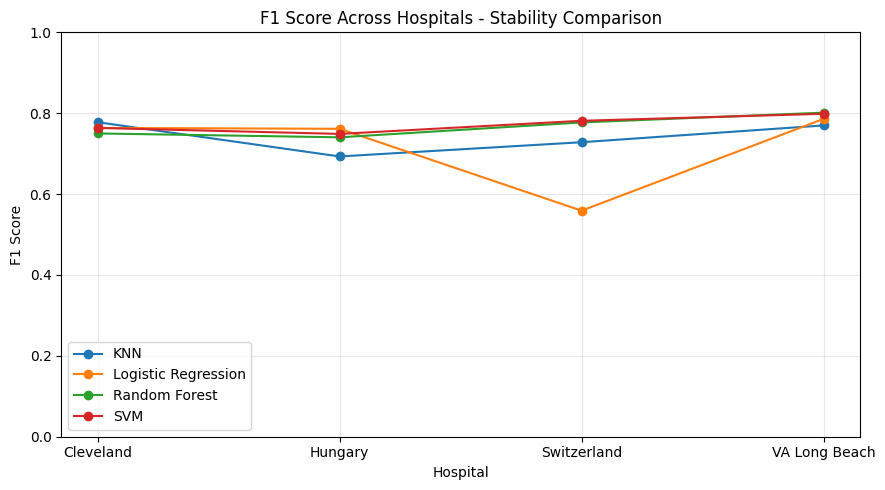

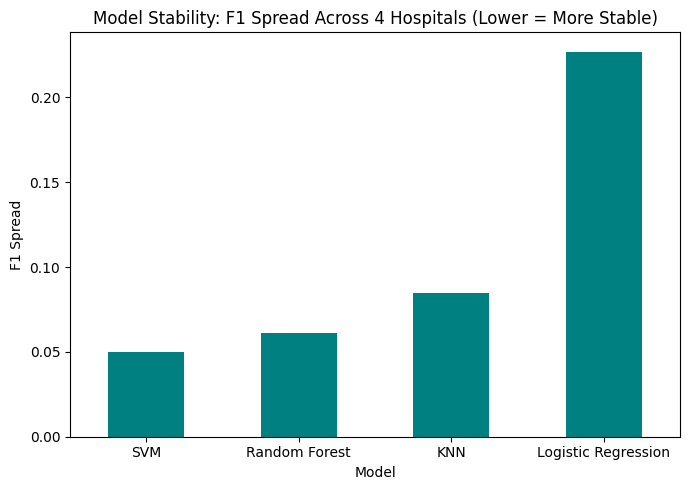

In [ ]:
import matplotlib.pyplot as plt

# Chart 1: F1 score across hospitals, one line per model - shows stability visually
plt.figure(figsize=(9,5))
for model_name in f1_pivot.index:
    hospital_scores = f1_pivot.loc[model_name, ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']]
    plt.plot(hospital_scores.index, hospital_scores.values, marker='o', label=model_name)

plt.title("F1 Score Across Hospitals - Stability Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Hospital")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cross_hospital_stability_chart.png")
plt.show()

# Chart 2: The spread itself, as a simple bar chart - the "headline" number
plt.figure(figsize=(7,5))
f1_pivot_sorted['Spread (Max-Min)'].plot(kind='bar', color='teal')
plt.title("Model Stability: F1 Spread Across 4 Hospitals (Lower = More Stable)")
plt.ylabel("F1 Spread")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("stability_spread_chart.png")
plt.show()